In [163]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
from utils import MEASURED_BANDWIDTH, MEASURED_BANDWIDTH_STR

In [164]:
algorithm_mapping = {
    "block_by_block": "block-by-block",
    "column_by_column": "column-by-column",
    "cusparse": "cuSparse",
    "row_per_thread_irrespective": "RPT-I",
    "row_per_thread_sync": "RPT-S",
    "row_per_thread": "RPT",
}

style_mapping = {
    "cusparse": ("o", "tab:blue"),
    "block_by_block": ("s", "tab:purple"),
    "column_by_column": ("^", "tab:red"),
    "row_per_thread_sync": ("D", "tab:green"),
    "row_per_thread": ("P", "tab:orange"),
    "row_per_thread_irrespective": ("*", "tab:brown"),
}

In [165]:
def process_df(df):
    df["dtype"] = df["dtype"].str.replace("torch.float", "float")
    df["times [ms]"] = df["times [ms]"].apply(ast.literal_eval)
    df.loc[
        (df["algorithm"].str.contains("bsr_block_by_block"))
        & (df["DOFs per element"] > 5),
        ["times [ms]"],
    ] = None
    df["time [ms]"] = df["times [ms]"].apply(
        lambda x: float("inf") if x is None else min(x)
    )
    return df

In [166]:
def memory_tput(row):
    dofs = row["DOFs"]
    dofs_per_el = row["DOFs per element"]
    nnz = row["nnz"]
    if row["dtype"] == "float32":
        bytes_per_value = 4
    elif row["dtype"] == "float64":
        bytes_per_value = 8
    else:
        raise ValueError(f"Unknown dtype: {row['dtype']}")
    bytes_per_index = 4

    time_s = row["time [ms]"] * 1e-3
    if time_s == 0 or pd.isna(time_s):
        return None

    if "csr" in row["algorithm"]:
        matrix_size = (
            nnz * bytes_per_value + nnz * bytes_per_index + (dofs + 1) * bytes_per_index
        )
    else:
        matrix_size = (
            nnz * bytes_per_value
            + (nnz // dofs_per_el // dofs_per_el) * bytes_per_index
            + (dofs // dofs_per_el + 1) * bytes_per_index
        )
    vector_size = dofs * bytes_per_value
    total_bytes = matrix_size + 2 * vector_size

    return total_bytes / time_s / 1e9  # GB/s

In [167]:
def get_memory_pivot(df):
    df["memory tput [GB/s]"] = df.apply(memory_tput, axis=1)
    pivot = df.pivot_table(
        values="memory tput [GB/s]",
        index="algorithm",
        columns=["dimension", "degree", "DOFs per element"],
        aggfunc="max",
    )
    return pivot

In [168]:
def plot_memory_pivot(ax, pivot, legend):
    for alg, data in pivot.iterrows():
        if "csr" in alg:
            continue

        correct_vals = data.values > 0
        idx = np.arange(len(data.values))[correct_vals]
        vals = data.values[correct_vals]

        marker, color = style_mapping[alg[4:]]

        ax.scatter(
            idx,
            vals,
            label=algorithm_mapping[alg[4:]] if legend else None,
            marker=marker,
            facecolors="none",
            edgecolors=color,
            s=50,
        )
    ax.set_xticks(
        range(len(pivot.columns)),
        [f"$p={deg}$\n$b={bs}$" for dim, deg, bs in pivot.columns],
    )
    ax.set_yticks([0, 500, 1000, 1500, MEASURED_BANDWIDTH])
    ax.grid(which="both", linestyle="--", linewidth=0.5, color="grey", axis="y")
    ax.set_xlim(-0.5, len(pivot.columns) - 0.5)
    ax.set_ylim(bottom=0, top=1870)

    ax.axhline(
        y=MEASURED_BANDWIDTH,
        color="red",
        linestyle="--",
        label=f"A100 bandwidth" if legend else None,
    )

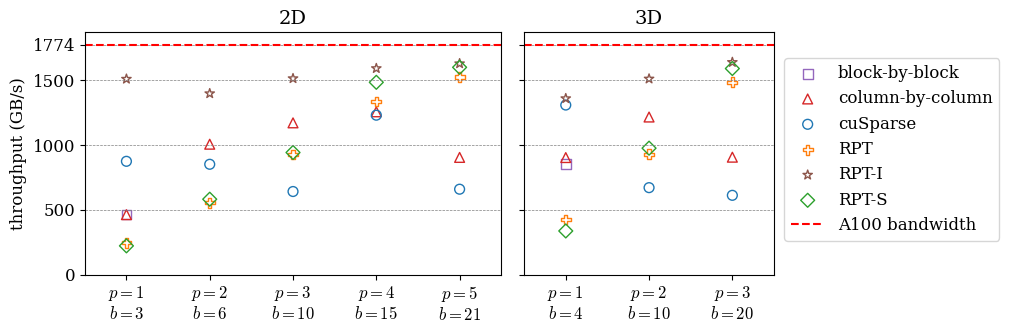

In [169]:
fig, ax = plt.subplots(
    figsize=(8, 3.5), ncols=2, width_ratios=[5, 3], sharey=True, tight_layout=True
)

df = process_df(pd.read_csv("../results/benchmark_bsrmv.csv"))
pivot_2d = get_memory_pivot(df[df.dimension == "2D"].copy())
plot_memory_pivot(ax[0], pivot_2d, legend=True)
ax[0].set_title("2D")
ax[0].set_ylabel("throughput (GB/s)")
pivot_3d = get_memory_pivot(df[df.dimension == "3D"].copy())
plot_memory_pivot(ax[1], pivot_3d, legend=False)
ax[1].set_title("3D")

fig.legend(bbox_to_anchor=(0.98, 0.55), loc="center left")
fig.savefig("../docs/images/bsrmv_memory_throughput.svg", bbox_inches="tight")

In [170]:
time_pivot = df.pivot_table(
    values="time [ms]",
    index=["dimension", "degree"],
    columns="algorithm",
    aggfunc="min",
)
for c in time_pivot.columns:
    time_pivot[c] = time_pivot["csr_cusparse"] / time_pivot[c]
time_pivot

algorithm         bsr_block_by_block  bsr_column_by_column  bsr_cusparse  \
dimension degree                                                           
2D        1                 0.486892              0.485955      0.917990   
          2                 0.000000              1.067513      0.903291   
          3                 0.000000              1.236661      0.677433   
          4                 0.000000              1.307552      1.280566   
          5                 0.000000              0.936904      0.682867   
3D        1                 0.892078              0.942796      1.365531   
          2                 0.000000              1.276533      0.704673   
          3                 0.000000              0.932706      0.630016   

algorithm         bsr_row_per_thread  bsr_row_per_thread_irrespective  \
dimension degree                                                        
2D        1                 0.258548                         1.584369   
          2                 0.589163                         1.482108   
          3                 0.978437                         1.598005   
          4                 1.390567                         1.656168   
          5                 1.579181                         1.686474   
3D        1                 0.444472                         1.418323   
          2                 0.975405                         1.585858   
          3                 1.527717                         1.686272   

algorithm         bsr_row_per_thread_sync  csr_cusparse  
dimension degree                                         
2D        1                      0.233405           1.0  
          2                      0.617386           1.0  
          3                      0.995004           1.0  
          4                      1.544456           1.0  
          5                      1.656567           1.0  
3D        1                      0.351956           1.0  
          2                      1.024357           1.0  
          3                      1.636425           1.0